Data processing and plot creation for SCLF distribution of 0.1 increments (for koppen figure)

In [ ]:
# load in tiles gpkg and folder with tif data

In [ ]:
# get pixel count of 1 for each *.tif and add to geopackage

In [1]:
import geopandas as gpd
from osgeo import gdal
import numpy as np
import os

# Configuration
base_folder = "../data/"
gpkg_path = "../data/SCLF_tiles_index.gpkg"

# Define ranges with their corresponding suffixes
ranges = {
    "0_01": "_0_01",           # Files end with _0_01.tif
    "01_02": "_01_02",         # Files end with _01_02.tif
    "02_03": "_02_03",         # Files end with _02_03.tif
    "03_04": "_03_04",         # Files end with _03_04.tif
    "04_05": "_04_05",         # Files end with _04_05.tif
    "05_06": "_05_06",         # Files end with _05_06.tif
    "06_07": "_06_07",         # Files end with _06_07.tif
    "07_08": "_07_08",         # Files end with _07_08.tif
    "08_09": "_08_09",         # Files end with _08_09.tif
    "09_1": "_09_1",         # Files end with _09_1.tif
}

# Load GeoPackage
gdf = gpd.read_file(gpkg_path)

# Extract coordinates
gdf['x'] = gdf['location'].str.extract(r'x(\d+)').astype(int)
gdf['y'] = gdf['location'].str.extract(r'y(\d+)').astype(int)

# Process each range
for range_name, suffix in ranges.items():
    print(f"Processing range: {range_name}")
    
    folder_path = os.path.join(base_folder, f"SCLF_model_{range_name}")
    
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"  Warning: Folder {folder_path} does not exist, skipping...")
        continue
    
    # Create column names
    pixel_col = f"pixels_{range_name}"
    area_col = f"area_km2_{range_name}"
    
    # Initialize columns
    gdf[pixel_col] = 0
    gdf[area_col] = 0.0
    
    # Count pixels for each tile
    for idx, location in enumerate(gdf['location']):
        tif_filename = location.replace('.tif', f'{suffix}.tif')
        tif_path = os.path.join(folder_path, tif_filename)
        
        if os.path.exists(tif_path):
            try:
                ds = gdal.Open(tif_path)
                if ds:
                    arr = ds.GetRasterBand(1).ReadAsArray()
                    pixel_count = int(np.sum(arr == 1))
                    gdf.at[idx, pixel_col] = pixel_count
                    gdf.at[idx, area_col] = pixel_count * 0.0009
                    ds = None
            except Exception as e:
                print(f"  Error processing {tif_filename}: {e}")
        
        # Print progress every 50 files
        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gdf)} files")
    
    # Print summary for this range
    total_pixels = gdf[pixel_col].sum()
    print(f"  Total pixels in {range_name}: {total_pixels:,}")

# Save results
output_path = "SCLF_tiles_01_increments.gpkg"
gdf.to_file(output_path, driver='GPKG')

print(f"\nResults saved to: {output_path}")

# Print final summary
print("\n=== FINAL SUMMARY ===")
for range_name in ranges.keys():
    pixel_col = f"pixels_{range_name}"
    area_col = f"area_km2_{range_name}"
    if pixel_col in gdf.columns:
        print(f"{range_name}:")
        print(f"  Pixels: {gdf[pixel_col].sum():,}")
        print(f"  Area: {gdf[area_col].sum():,.4f} km²")

Processing range: 0_01


/env/lib/python3.10/site-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


  Processed 50/271 files
  Processed 100/271 files
  Processed 150/271 files
  Processed 200/271 files
  Processed 250/271 files
  Total pixels in 0_01: 186,924
Processing range: 01_02
  Processed 50/271 files
  Processed 100/271 files
  Processed 150/271 files
  Processed 200/271 files
  Processed 250/271 files
  Total pixels in 01_02: 2,510,583
Processing range: 02_03
  Processed 50/271 files
  Processed 100/271 files
  Processed 150/271 files
  Processed 200/271 files
  Processed 250/271 files
  Total pixels in 02_03: 3,668,054
Processing range: 03_04
  Processed 50/271 files
  Processed 100/271 files
  Processed 150/271 files
  Processed 200/271 files
  Processed 250/271 files
  Total pixels in 03_04: 4,503,603
Processing range: 04_05
  Processed 50/271 files
  Processed 100/271 files
  Processed 150/271 files
  Processed 200/271 files
  Processed 250/271 files
  Total pixels in 04_05: 5,541,991
Processing range: 05_06
  Processed 50/271 files
  Processed 100/271 files
  Processed 

In [2]:
gdf

,location,geometry,x,y,pixels_0_01,area_km2_0_01,pixels_01_02,area_km2_01_02,pixels_02_03,area_km2_02_03,...,pixels_05_06,area_km2_05_06,pixels_06_07,area_km2_06_07,pixels_07_08,area_km2_07_08,pixels_08_09,area_km2_08_09,pixels_09_1,area_km2_09_1
0,x26y40_SCLF_model.tif,"POLYGON ((-1920000.000 -2976000.000, -1824000....",26,40,1,0.0009,55,0.0495,259,0.2331,...,85,0.0765,117,0.1053,105,0.0945,1,0.0009,0,0.0000
1,x26y41_SCLF_model.tif,"POLYGON ((-1920000.000 -2880000.000, -1824000....",26,41,5,0.0045,125,0.1125,58,0.0522,...,140,0.1260,120,0.1080,37,0.0333,3,0.0027,1,0.0009
2,x26y42_SCLF_model.tif,"POLYGON ((-1920000.000 -2784000.000, -1824000....",26,42,0,0.0000,0,0.0000,17,0.0153,...,254,0.2286,107,0.0963,68,0.0612,2,0.0018,0,0.0000
3,x26y43_SCLF_model.tif,"POLYGON ((-1920000.000 -2688000.000, -1824000....",26,43,0,0.0000,0,0.0000,0,0.0000,...,72,0.0648,115,0.1035,2443,2.1987,4897,4.4073,23141,20.8269
4,x26y44_SCLF_model.tif,"POLYGON ((-1920000.000 -2592000.000, -1824000....",26,44,0,0.0000,0,0.0000,0,0.0000,...,17,0.0153,1,0.0009,0,0.0000,0,0.0000,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,x67y40_SCLF_model.tif,"POLYGON ((2016000.000 -2976000.000, 2112000.00...",67,40,264,0.2376,9410,8.4690,22801,20.5209,...,60683,54.6147,59117,53.2053,45007,40.5063,86420,77.7780,20975,18.8775
267,x67y41_SCLF_model.tif,"POLYGON ((2016000.000 -2880000.000, 2112000.00...",67,41,860,0.7740,47975,43.1775,89071,80.1639,...,112437,101.1933,99126,89.2134,111107,99.9963,131170,118.0530,20337,18.3033
268,x67y42_SCLF_model.tif,"POLYGON ((2016000.000 -2784000.000, 2112000.00...",67,42,690,0.6210,21937,19.7433,27807,25.0263,...,26573,23.9157,20825,18.7425,28727,25.8543,27593,24.8337,2409,2.1681
269,x68y41_SCLF_model.tif,"POLYGON ((2112000.000 -2880000.000, 2208000.00...",68,41,0,0.0000,0,0.0000,0,0.0000,...,401,0.3609,85,0.0765,11,0.0099,1,0.0009,0,0.0000


In [10]:
import rasterstats

# Perform zonal statistics to get majority value
stats = rasterstats.zonal_stats(
    gdf,
    '../data/koppen/koppen_geiger_0p1_AUS_EPSG3577.tif',
    stats=['majority'],  # Get majority value
    categorical=True,    # Important for getting majority of categorical data
    nodata=0,       # Adjust based on your raster's nodata value
    geojson_out=True    # Returns GeoJSON format with stats
)

# Convert results to GeoDataFrame
gdf_stats = gpd.GeoDataFrame.from_features(stats)

# If you want to add just the majority column to your original gdf
gdf['koppen_value'] = [feat['properties']['majority'] for feat in stats]

output_path = "SCLF_tiles_01_increments_koppen.gpkg"
gdf.to_file(output_path, driver='GPKG')

In [11]:
gdf

,location,geometry,x,y,pixels_0_01,area_km2_0_01,pixels_01_02,area_km2_01_02,pixels_02_03,area_km2_02_03,...,area_km2_05_06,pixels_06_07,area_km2_06_07,pixels_07_08,area_km2_07_08,pixels_08_09,area_km2_08_09,pixels_09_1,area_km2_09_1,koppen_value
0,x26y40_SCLF_model.tif,"POLYGON ((-1920000.000 -2976000.000, -1824000....",26,40,1,0.0009,55,0.0495,259,0.2331,...,0.0765,117,0.1053,105,0.0945,1,0.0009,0,0.0000,6.0
1,x26y41_SCLF_model.tif,"POLYGON ((-1920000.000 -2880000.000, -1824000....",26,41,5,0.0045,125,0.1125,58,0.0522,...,0.1260,120,0.1080,37,0.0333,3,0.0027,1,0.0009,6.0
2,x26y42_SCLF_model.tif,"POLYGON ((-1920000.000 -2784000.000, -1824000....",26,42,0,0.0000,0,0.0000,17,0.0153,...,0.2286,107,0.0963,68,0.0612,2,0.0018,0,0.0000,4.0
3,x26y43_SCLF_model.tif,"POLYGON ((-1920000.000 -2688000.000, -1824000....",26,43,0,0.0000,0,0.0000,0,0.0000,...,0.0648,115,0.1035,2443,2.1987,4897,4.4073,23141,20.8269,4.0
4,x26y44_SCLF_model.tif,"POLYGON ((-1920000.000 -2592000.000, -1824000....",26,44,0,0.0000,0,0.0000,0,0.0000,...,0.0153,1,0.0009,0,0.0000,0,0.0000,0,0.0000,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,x67y40_SCLF_model.tif,"POLYGON ((2016000.000 -2976000.000, 2112000.00...",67,40,264,0.2376,9410,8.4690,22801,20.5209,...,54.6147,59117,53.2053,45007,40.5063,86420,77.7780,20975,18.8775,14.0
267,x67y41_SCLF_model.tif,"POLYGON ((2016000.000 -2880000.000, 2112000.00...",67,41,860,0.7740,47975,43.1775,89071,80.1639,...,101.1933,99126,89.2134,111107,99.9963,131170,118.0530,20337,18.3033,14.0
268,x67y42_SCLF_model.tif,"POLYGON ((2016000.000 -2784000.000, 2112000.00...",67,42,690,0.6210,21937,19.7433,27807,25.0263,...,23.9157,20825,18.7425,28727,25.8543,27593,24.8337,2409,2.1681,14.0
269,x68y41_SCLF_model.tif,"POLYGON ((2112000.000 -2880000.000, 2208000.00...",68,41,0,0.0000,0,0.0000,0,0.0000,...,0.3609,85,0.0765,11,0.0099,1,0.0009,0,0.0000,2.0


In [12]:
# Get all pixel and area column names
pixel_cols = [col for col in gdf.columns if col.startswith('pixels_')]
area_cols = [col for col in gdf.columns if col.startswith('area_km2_')]

# Group by koppen_value and sum
grouped = gdf.groupby('koppen_value')[pixel_cols + area_cols].sum().reset_index()

# If you want to keep track of count of polygons per group
grouped['polygon_count'] = gdf.groupby('koppen_value').size().values

In [13]:
grouped

,koppen_value,pixels_0_01,pixels_01_02,pixels_02_03,pixels_03_04,pixels_04_05,pixels_05_06,pixels_06_07,pixels_07_08,pixels_08_09,...,area_km2_01_02,area_km2_02_03,area_km2_03_04,area_km2_04_05,area_km2_05_06,area_km2_06_07,area_km2_07_08,area_km2_08_09,area_km2_09_1,polygon_count
0,1.0,1670,41369,45914,42298,35178,41993,51351,46010,32209,...,37.2321,41.3226,38.0682,31.6602,37.7937,46.2159,41.4090,28.9881,17.7732,1
1,2.0,1310,15585,23567,28596,36230,58983,71227,50731,33692,...,14.0265,21.2103,25.7364,32.6070,53.0847,64.1043,45.6579,30.3228,15.0021,5
2,3.0,125589,1651187,2256663,2685776,3093635,2472494,1842315,1333836,306520,...,1486.0683,2030.9967,2417.1984,2784.2715,2225.2446,1658.0835,1200.4524,275.8680,15.2424,96
3,4.0,17860,51436,19265,12831,11000,11685,10337,11316,7086,...,46.2924,17.3385,11.5479,9.9000,10.5165,9.3033,10.1844,6.3774,23.2713,28
4,5.0,375,7531,16574,25235,24103,8877,5236,4488,488,...,6.7779,14.9166,22.7115,21.6927,7.9893,4.7124,4.0392,0.4392,0.9045,10
5,6.0,5653,59520,66632,63951,55745,49723,37778,37809,6836,...,53.5680,59.9688,57.5559,50.1705,44.7507,34.0002,34.0281,6.1524,0.4941,20
6,7.0,8497,127924,140670,170535,216670,157474,49368,31346,13990,...,115.1316,126.6030,153.4815,195.0030,141.7266,44.4312,28.2114,12.5910,2.1078,18
7,8.0,4059,57545,88409,94066,95430,79524,34347,37986,21858,...,51.7905,79.5681,84.6594,85.8870,71.5716,30.9123,34.1874,19.6722,0.6489,8
8,9.0,4618,142863,247641,247935,312464,293189,130451,58811,66211,...,128.5767,222.8769,223.1415,281.2176,263.8701,117.4059,52.9299,59.5899,4.1373,25
9,11.0,78,6053,14808,24543,31479,29608,31471,48707,28517,...,5.4477,13.3272,22.0887,28.3311,26.6472,28.3239,43.8363,25.6653,9.1989,2


Plot saved as: koppen_plots/koppen_Cwa_11_area_distribution.png


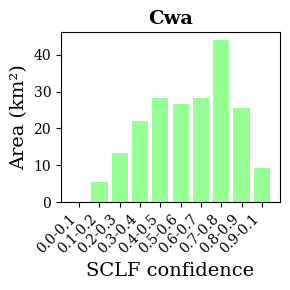

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Köppen-Geiger classification dictionary with RGB colors from Beck et al. (2023)
koppen_dict = {
    1: {"code": "Af", "name": "Tropical, rainforest", "color": [0, 0, 255]},
    2: {"code": "Am", "name": "Tropical, monsoon", "color": [0, 120, 255]},
    3: {"code": "Aw", "name": "Tropical, savannah", "color": [70, 170, 250]},
    4: {"code": "BWh", "name": "Arid, desert, hot", "color": [255, 0, 0]},
    5: {"code": "BWk", "name": "Arid, desert, cold", "color": [255, 150, 150]},
    6: {"code": "BSh", "name": "Arid, steppe, hot", "color": [245, 165, 0]},
    7: {"code": "BSk", "name": "Arid, steppe, cold", "color": [255, 220, 100]},
    8: {"code": "Csa", "name": "Temperate, dry summer, hot summer", "color": [255, 255, 0]},
    9: {"code": "Csb", "name": "Temperate, dry summer, warm summer", "color": [200, 200, 0]},
    10: {"code": "Csc", "name": "Temperate, dry summer, cold summer", "color": [150, 150, 0]},
    11: {"code": "Cwa", "name": "Temperate, dry winter, hot summer", "color": [150, 255, 150]},
    12: {"code": "Cwb", "name": "Temperate, dry winter, warm summer", "color": [100, 200, 100]},
    13: {"code": "Cwc", "name": "Temperate, dry winter, cold summer", "color": [50, 150, 50]},
    14: {"code": "Cfa", "name": "Temperate, no dry season, hot summer", "color": [200, 255, 80]},
    15: {"code": "Cfb", "name": "Temperate, no dry season, warm summer", "color": [100, 255, 80]},
    16: {"code": "Cfc", "name": "Temperate, no dry season, cold summer", "color": [50, 200, 0]},
    17: {"code": "Dsa", "name": "Cold, dry summer, hot summer", "color": [255, 0, 255]},
    18: {"code": "Dsb", "name": "Cold, dry summer, warm summer", "color": [200, 0, 200]},
    19: {"code": "Dsc", "name": "Cold, dry summer, cold summer", "color": [150, 50, 150]},
    20: {"code": "Dsd", "name": "Cold, dry summer, very cold winter", "color": [150, 100, 150]},
    21: {"code": "Dwa", "name": "Cold, dry winter, hot summer", "color": [170, 175, 255]},
    22: {"code": "Dwb", "name": "Cold, dry winter, warm summer", "color": [90, 120, 220]},
    23: {"code": "Dwc", "name": "Cold, dry winter, cold summer", "color": [75, 80, 180]},
    24: {"code": "Dwd", "name": "Cold, dry winter, very cold winter", "color": [50, 0, 135]},
    25: {"code": "Dfa", "name": "Cold, no dry season, hot summer", "color": [0, 255, 255]},
    26: {"code": "Dfb", "name": "Cold, no dry season, warm summer", "color": [55, 200, 255]},
    27: {"code": "Dfc", "name": "Cold, no dry season, cold summer", "color": [0, 125, 125]},
    28: {"code": "Dfd", "name": "Cold, no dry season, very cold winter", "color": [0, 70, 95]},
    29: {"code": "ET", "name": "Polar, tundra", "color": [178, 178, 178]},
    30: {"code": "EF", "name": "Polar, frost", "color": [102, 102, 102]}
}

# Function to convert RGB to matplotlib color
def rgb_to_color(rgb_array):
    """Convert RGB array [0-255] to matplotlib color [0-1]"""
    return [c/255 for c in rgb_array]

# Function to format labels with decimal points
def format_label(label_str):
    """Convert labels like '0-01' to '0-0.1'"""
    parts = label_str.split('-')
    if len(parts) == 2:
        # Format start and end with decimal point
        start = float(parts[0]) / 10
        end = float(parts[1]) / 10
        return f"{start:.1f}-{end:.1f}"
    return label_str

# Main plotting function
def plot_koppen_area_distribution(grouped, koppen_value_to_plot=6.0, save_plot=False, output_dir='koppen_plots'):
    # Get Köppen classification info
    koppen_info = koppen_dict[koppen_value_to_plot]
    koppen_code = koppen_info["code"]
    koppen_name = koppen_info["name"]
    koppen_color = rgb_to_color(koppen_info["color"])
    
    # Filter data for this Köppen value
    filtered = grouped[grouped['koppen_value'] == koppen_value_to_plot]
    
    # Get area columns in order
    area_cols = [col for col in grouped.columns if col.startswith('area_km2_')]
    
    # Sort them in the correct order
    def get_sort_key(col_name):
        parts = col_name.split('_')
        if len(parts) >= 3:
            try:
                start = float(parts[-2])
                end = float(parts[-1])
                return start
            except:
                return 0
        return 0
    
    area_cols_sorted = sorted(area_cols, key=get_sort_key)
    
    # Get the area values
    area_values = filtered[area_cols_sorted].iloc[0].values
    
    # Create labels for the bars with decimal format
    raw_labels = [col.replace('area_km2_', '').replace('_', '-') for col in area_cols_sorted]
    labels = [format_label(label) for label in raw_labels]
    
    # Create the bar chart
    fig, ax = plt.subplots(figsize=(3, 3))
    
    # Create bars with the specific Köppen color
    x_positions = np.arange(len(labels))
    bars = ax.bar(x_positions, area_values, width=0.8, color=koppen_color)
    
    # Customize the chart with classification code and name in title
    plt.rcParams['font.family'] = 'serif'
    # ax.set_title(f'{koppen_code}: {koppen_name}', fontsize=14, fontweight='bold')
    ax.set_title(f'{koppen_code}', fontsize=14, fontweight='bold')
    ax.set_xlabel('SCLF confidence', fontsize=14)
    ax.set_ylabel('Area (km²)', fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        # Create output directory if it doesn't exist
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        # Create filename
        filename = f"{output_dir}/koppen_{koppen_code}_{koppen_value_to_plot:.0f}_area_distribution.png"
        
        # Save at 300 DPI
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
        print(f"Plot saved as: {filename}")
    
    plt.show()
    plt.close(fig)  # Close the figure to free memory

# Example usage:
# plot_koppen_area_distribution(grouped, koppen_value_to_plot=1.0)
plot_koppen_area_distribution(grouped, koppen_value_to_plot=11.0, save_plot=True)